In [2]:
import sys

sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy

### State preparation with 1 ancilla and 2 excitations on a total of 35 qubits

In [3]:
def prep_psi_0(qc: QuantumCircuit):
    qc.cx(34, 4)
    qc.cx(34, 21)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(34, 4, ctrl_state="0")
    qc.cx(34, 21, ctrl_state="0")
    return qc

### Test if state prep works as expected

In [4]:
from qiskit_aer import StatevectorSimulator
from qiskit_aer.primitives import SamplerV2

# sv = StatevectorSimulator()
sampler = SamplerV2(options={"backend_options": {"method": "matrix_product_state"}})
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc.measure_all()

job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'10000000000001000000000000000010000': 512,
 '00000000000000000000000000000000000': 512}

In [5]:
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc = prep_psi_0_by_0(qc)
qc.measure_all()
job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'00000000000001000000000000000010000': 510,
 '10000000000001000000000000000010000': 514}

## Hardware experiments

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
# QiskitRuntimeService.save_account(
#   token=token,
#   channel="ibm_cloud", # `channel` distinguishes between different account types.
#   instance="crn:v1:bluemix:public:quantum-computing:us-east:a/6c63dae5281147f1a0449b36e0aaba3a:068b8d3f-2983-4154-822a-f19a296847ec::", # Copy the instance CRN from the Instance section on the dashboard.
# )

service = QiskitRuntimeService()
backend = service.backend("ibm_torino")

In [ ]:
from qiskit.transpiler import generate_preset_pass_manager


t_steps = 8
num_qubits = 34
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)

qubit_subset = (
    list(range(42, 48))
    + [35]
    + list(range(25, 30))
    + [36, 48, 49, 50, 54]
    + list(range(61, 66))
    + list(range(66, 70))
    + [56, 73, 82, 83, 84, 85, 86, 74]
)
# remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
# rev_map = {val: key for key, val in remap.items()}


cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
# ent_dec = [(rev_map[i], rev_map[j]) for i, j in edge_list]


def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()


H = Heisenberg(1, num_qubits, edge_list)

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_qubits).compose(qc_temp)

# time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)
real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * 34, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * 34, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy()

init_layout = qubit_subset + [55]  # ancilla at qubit 55 on torino
pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=init_layout
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

print(
    f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)

Max circuit depth:73


# Circuit execution

## Run as individual jobs to allow more shots

In [91]:
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions

estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 800000  # Try going upto 1000000
estimator.options.resilience_level = 2
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.resilience.zne.noise_factors = (1, 1.3, 1.6)  # use fractional folding
estimator.options.resilience.zne.extrapolator = (
    "linear"  # exponential fit showed high std's, use this instead.
)
# estimator.options.experimental = {"execution_path": "gen3-turbo"}

est_jobs = []
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circ = circs[i][j]
        else:
            circ = circs[j][i]
        est_jobs.append(
            estimator.run(
                [
                    (
                        circ,
                        [
                            real_obs_H.apply_layout(circ.layout),
                            imag_obs_H.apply_layout(circ.layout),
                            real_obs_S.apply_layout(circ.layout),
                            imag_obs_S.apply_layout(circ.layout),
                        ],
                    )
                ]
            )
        )

In [93]:
job_results = [job.result() for job in est_jobs]
print([job for job in est_jobs if job.errored()])  # check if any of the jobs errored.

[]


In [595]:
job_results[0][0].data

DataBin(evs=np.ndarray(<shape=(4,), dtype=float64>), stds=np.ndarray(<shape=(4,), dtype=float64>), evs_noise_factors=np.ndarray(<shape=(4, 3), dtype=float64>), stds_noise_factors=np.ndarray(<shape=(4, 3), dtype=float64>), ensemble_stds_noise_factors=np.ndarray(<shape=(4, 3), dtype=float64>), evs_extrapolated=np.ndarray(<shape=(4, 1, 4), dtype=float64>), stds_extrapolated=np.ndarray(<shape=(4, 1, 4), dtype=float64>), shape=(4,))

In [94]:
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
idx = 0
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            H_tilde[i, j] = (
                job_results[idx][0].data.evs[0] + 1j * job_results[idx][0].data.evs[1]
            )
            S_tilde[i, j] = (
                job_results[idx][0].data.evs[2] + 1j * job_results[idx][0].data.evs[3]
            )
        else:
            H_tilde[i, j] = np.conj(H_tilde[j, i])
            S_tilde[i, j] = np.conj(S_tilde[j, i])
        idx += 1

In [96]:
from sympy import Matrix

Matrix(S_tilde)

Matrix([
[   0.959575828823403 - 0.00857742061309832*I,    0.853644935323086 + 0.418176280511675*I,     0.322306270096692 + 0.53406134050212*I,  -0.0604873934886156 + 0.527410358098642*I, -0.149658109243103 + 0.232048269271491*I,  -0.112897581585932 + 0.0838076172071938*I, -0.0641644224364905 + 0.0256418911729134*I, -0.0145032378661772 - 0.000942306597573612*I],
[     0.853644935323086 - 0.418176280511675*I,    1.02470389252582 - 0.0417487614520974*I,     0.80975080872664 + 0.538049079234427*I,    0.248895925146419 + 0.721160664558261*I, 0.0114287671699229 + 0.586514652907093*I,    -0.176416485190081 + 0.27465530645776*I,  -0.131920433355231 + 0.0893072341366739*I,   -0.0626920226119782 + 0.0090969723532626*I],
[      0.322306270096692 - 0.53406134050212*I,     0.80975080872664 - 0.538049079234427*I,   1.05075628272806 + 0.00340987329899902*I,    0.818956670308778 + 0.416913481429479*I,  0.238775000195693 + 0.611516013778219*I, -0.00986057924252739 + 0.540606927700259*I,   -0.157005240

In [97]:
Matrix(H_tilde)

Matrix([
[   26.814284896499 - 0.265352296555781*I,    18.6785769981071 + 8.69132940707286*I,   7.21646854457641 + 8.61683138017184*I,  1.56586756707595 + 8.95790207563456*I, -0.372146007313353 + 3.80935237734334*I,  -0.472579441313158 + 2.08885924608904*I, -0.396913480737988 + 1.01822023613189*I, -0.114974692104677 + 0.390386914780405*I],
[   18.6785769981071 - 8.69132940707286*I,    25.7611186973126 - 1.27309880717613*I,     17.4834792691221 + 10.44377463844*I,  5.61565909972372 + 11.3561394551261*I,   2.69291255098648 + 7.47667364009326*I, -0.0260345473844147 + 4.30863422848747*I,  -0.65310493955123 + 1.75490842836544*I, -0.579642036234153 + 0.886440530792838*I],
[   7.21646854457641 - 8.61683138017184*I,      17.4834792691221 - 10.44377463844*I,  22.2312571856084 - 0.437184827517077*I,  15.2592186376797 + 7.03015639314767*I,   5.07758924771668 + 7.77065616584359*I,     2.3614604774124 + 6.22225712970981*I, -0.210220747753656 + 2.68298083999676*I,   -0.667239429035696 + 1.8975700554

In [30]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    # make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T
    print(len(truncated_eigvals))
    return truncated_eigvecs


def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        # solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        E, c = scipy.linalg.eig(a=A, b=B)
        idx = E.argsort()[::-1]
        eigvals = E[idx]
        eigvecs = c[:, idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:, -1])
        print(min(eigvals))

    return GSEs, ground_states, V_eps

## Run on simulator for comparison

In [17]:
from qiskit_aer.noise import NoiseModel

nm = NoiseModel()
nm.from_backend(backend=backend)

<NoiseModel on ['reset', 'x', 'measure', 'sx', 'id', 'cz']>

In [82]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2

from qiskit_aer.noise import NoiseModel

backend = service.backend("ibm_torino")

t_steps = 8
n_qubits = 34  # number of data qubits
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim_non_noisy = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_non_noisy = np.zeros([t_steps, t_steps], dtype=complex)

delta_t = np.pi / 20
synth = LieTrotter(reps=1)
num_shots = 80000

H = Heisenberg(1, n_qubits, edge_list)

# Rxyz_circ = QuantumCircuit(2)
# Rxyz_circ.rxx(2 * delta_t, 0, 1)
# Rxyz_circ.ryy(2 * delta_t, 0, 1)
# Rxyz_circ.rzz(2 * delta_t, 0, 1)
# Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
# qc_temp = QuantumCircuit(n_qubits)
# for edge in edge_list:
#     qc_temp.append(Rxyz_instr, edge)
# time_evol = QuantumCircuit(n_qubits).compose(qc_temp)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * n_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * n_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state"} ,# "noise_model": nm},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_non_noisy[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_non_noisy[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_non_noisy[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_non_noisy[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [83]:
delta_t = np.pi / 30
synth = LieTrotter(reps=1)
num_shots = 800000
H_tilde_sim_noisy_pb30 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb30 = np.zeros([t_steps, t_steps], dtype=complex)

H = Heisenberg(1, num_qubits, edge_list)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state", "noise_model": nm},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb30[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb30[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb30[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb30[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [84]:
delta_t = np.pi / 20
synth = LieTrotter(reps=1)
num_shots = 800000
H_tilde_sim_noisy_pb20 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb20 = np.zeros([t_steps, t_steps], dtype=complex)

H = Heisenberg(1, num_qubits, edge_list)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state", "noise_model": nm},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb20[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb20[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb20[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb20[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [85]:
delta_t = np.pi / 10
synth = LieTrotter(reps=1)
num_shots = 800000
H_tilde_sim_noisy_pb10 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb10 = np.zeros([t_steps, t_steps], dtype=complex)

H = Heisenberg(1, num_qubits, edge_list)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state", "noise_model": nm},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb10[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb10[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb10[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb10[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [86]:
delta_t = np.pi / 40
synth = LieTrotter(reps=1)
num_shots = 800000
H_tilde_sim_noisy_pb40 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb40 = np.zeros([t_steps, t_steps], dtype=complex)

H = Heisenberg(1, num_qubits, edge_list)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state", "noise_model": nm},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb40[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb40[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb40[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb40[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [90]:
delta_t = np.pi / 15
synth = LieTrotter(reps=1)
num_shots = 800000
H_tilde_sim_noisy_pb15 = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy_pb15 = np.zeros([t_steps, t_steps], dtype=complex)

H = Heisenberg(1, num_qubits, edge_list)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state", "noise_model": nm},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb15[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb15[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy_pb15[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy_pb15[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

1
(28.013295981143017+0.009456128923399566j)
2
(1.1317950204093845+0.0010867014022680286j)
3
(0.04839868997846598+0.0010591435123929412j)
4
(0.0025396271044517823+0.0005655252609359435j)
5
(0.0016214389229204558+0.00022518333216042772j)
6
(0.0003263608240771361+0.0019980037927723455j)
7
(0.0001027639348827969+0.001513842008921488j)
8
(-0.0006062486752385631+0.0024368733004348168j)
1
(27.97473077778186-0.0007151120058139103j)
2
(24.09992676290309+0.07778247361802537j)
3
(20.999341753596575+3.1460868945634948j)
4
(2.899624032320666+2.9152502207460507j)
5
(0.24386625707753656+0.6492347070983675j)
5
(9.06267465428381-5.367793281669259j)
6
(-9.273088278538733-10.86572360945415j)
7
(-0.38000156255337403-0.5467086881525274j)
1
(28.0418274938804+0.06779431413350931j)
2
(24.5067938062674+0.09744914026088351j)
3
(22.825418356928306+0.2848551874471314j)
4
(22.120080361960206+0.17692550348363092j)
4
(21.411768799127955-0.033102483369022155j)
5
(21.805082750976364+0.6245735464291903j)
6
(-7.2908798

Text(0, 0.5, 'Ground state energy')

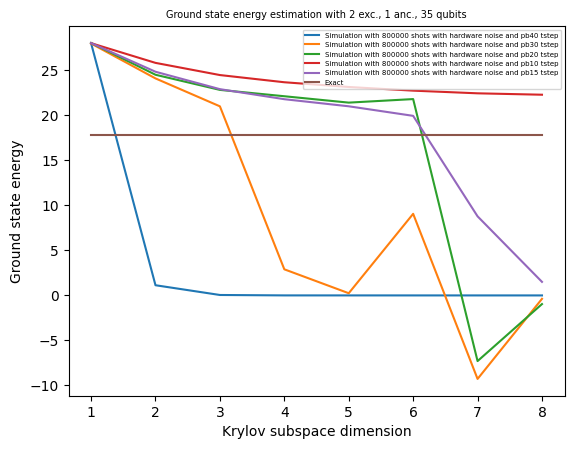

In [93]:
threshold = 1e-4
GSEs_sim_noisy_pb40, _, _ = E_vs_D(H_tilde_sim_noisy_pb40, S_tilde_sim_noisy_pb10,threshold)
GSEs_sim_noisy_pb30, _, _ = E_vs_D(H_tilde_sim_noisy_pb30, S_tilde_sim_noisy_pb30,threshold)
GSEs_sim_noisy_pb20, _, _ = E_vs_D(H_tilde_sim_noisy_pb20, S_tilde_sim_noisy_pb20,threshold)
GSEs_sim_noisy_pb10, _, _ = E_vs_D(H_tilde_sim_noisy_pb10, S_tilde_sim_noisy_pb10,threshold)
GSEs_sim_noisy_pb15, _, _ = E_vs_D(H_tilde_sim_noisy_pb15, S_tilde_sim_noisy_pb15,threshold)
# GSEs, _, _ = E_vs_D(H_tilde, S_tilde, 1 /50)
# plt.plot(list(range(1, len(S_tilde_sim_non_noisy) + 1)),
#         GSEs, label=f"Hardware with {num_shots} shots and {delta_t} step-size"
#)  # Ground-state energies
plt.plot(
    list(range(1, len(S_tilde_sim_non_noisy) + 1)),
         GSEs_sim_noisy_pb40,
    label=f"Simulation with {num_shots} shots with hardware noise and pb40 tstep",
)
plt.plot(
    list(range(1, len(S_tilde_sim_non_noisy) + 1)),
         GSEs_sim_noisy_pb30,
    label=f"Simulation with {num_shots} shots with hardware noise and pb30 tstep",
)
plt.plot(
    list(range(1, len(S_tilde_sim_non_noisy) + 1)),
         GSEs_sim_noisy_pb20,
    label=f"Simulation with {num_shots} shots with hardware noise and pb20 tstep",
)
plt.plot(
    list(range(1, len(S_tilde_sim_non_noisy) + 1)),
         GSEs_sim_noisy_pb10,
    label=f"Simulation with {num_shots} shots with hardware noise and pb10 tstep",
)
plt.plot(
    list(range(1, len(S_tilde_sim_non_noisy) + 1)),
         GSEs_sim_noisy_pb15,
    label=f"Simulation with {num_shots} shots with hardware noise and pb15 tstep",
)
plt.plot(
    list(range(1, len(S_tilde_sim_non_noisy)+1)),
    17.81817798453781 * np.ones(t_steps),
    label="Exact",
)
plt.title("Ground state energy estimation with 2 exc., 1 anc., 35 qubits", fontsize=7)
plt.legend(fontsize = 5,loc="upper right")
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

In [42]:
delta_t = np.pi / 20
synth = LieTrotter(reps=1)
num_shots = 80000
H_tilde_sim_noisy = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy = np.zeros([t_steps, t_steps], dtype=complex)

H = Heisenberg(1, num_qubits, edge_list)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * num_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * num_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state", "noise_model": nm},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [636]:
for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

In [ ]:
from qiskit_aer.primitives import SamplerV2
simulator = SamplerV2(default_shots=800000,
    options={
        "backend_options": {"method": "matrix_product_state","noise_model": nm},
    }
)
for i in range(t_steps):
    for j in range(t_steps):    
        if circuits[i][j] is not None:
            circuits[i][j].measure_all()
            s_job = simulator.run([circuits[i][j]])
        else:
            circuits[j][i].measure_all()
            s_job = simulator.run([circuits[j][i]])

        print([x.count('1') for x in list(s_job.result()[0].data.meas.get_counts().keys()) if (x[1:].count('1') != 2)])

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


In [72]:
sjobs=[]
simulator = SamplerV2(default_shots=800000,
    options={
        "backend_options": {"method": "matrix_product_state","noise_model": nm},
    }
)
for i in range(t_steps):
    for j in range(t_steps):    
        if circuits[i][j] is not None:
            circuits[i][j].measure_all()
            s_job = simulator.run([circuits[i][j]])
            sjobs.append(s_job)
        else:
            circuits[j][i].measure_all()
            s_job = simulator.run([circuits[j][i]])
            sjobs.append(s_job)

In [73]:
jobs_res = [job.result() for job in sjobs]

In [80]:
jobs_res[0][0].data.meas.get_counts()

{'10000000000001000000000000000010000': 399830,
 '00000000000001000000000000000010000': 400170}

In [104]:
[x for x in jobs_res[53][0].data.meas.get_counts().keys() if (x[1:].count('1') != 2)]

[]

## Exact diagonalisation for comparison

In [547]:
# Method from Krylov tutorial
import itertools as it
import scipy as sp
from qiskit.quantum_info import Pauli


def n_particle_gs(H_op, n_qubits, n_exc):
    """
    Find the ground state of the n particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    n_exc = n_exc
    sub_dimn = int(sp.special.comb(n_qubits, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    n_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states
    for i, i_set in enumerate(sparse_vecs):
        for j, j_set in enumerate(sparse_vecs):
            if len(i_set.symmetric_difference(j_set)) <= 2:

                for p_x, p_z, coeff in zip(H_x, H_z, H_c):

                    if i_set.symmetric_difference(j_set) == p_x:
                        sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                    else:
                        sgn = 0

                    n_particle_H[i, j] += sgn * coeff

    eige, eigv = np.linalg.eigh(n_particle_H)
    gs_en = eige[0]  # min(eige)
    gs_vec = eigv[:, 0]
    print("n_exc particle ground state energy: ", gs_en)
    return gs_en, gs_vec, n_particle_H


n_qubits = 34
edge_list = edge_list
H = Heisenberg(1, n_qubits, edge_list)
en, state, subspace_h = n_particle_gs(H, n_qubits, 2)
# print(np.linalg.norm(subspace_h,ord=2))

n_exc 2 , subspace dimension 561
n_exc particle ground state energy:  17.81817798453781
